# 05 — Summary Report

Executive-style findings notebook. Compile all results into a clean, presentable analytical summary — the kind you'd hand to a supervisor or brief to a non-technical audience.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.family": "sans-serif"})

df_states    = pd.read_csv("../data/raw_states.csv",  parse_dates=["time_utc"])
df_conflicts = pd.read_csv("../data/conflicts.csv")
has_conflicts = len(df_conflicts) > 0 and "severity" in df_conflicts.columns

REPORT_DATE = datetime.utcnow().strftime("%Y-%m-%d %H:%MZ")
print(f"Report generated: {REPORT_DATE}")
print(f"Traffic records:  {len(df_states)}")
print(f"Conflict events:  {len(df_conflicts)}")

Report generated: 2026-03-12 03:25Z
Traffic records:  310
Conflict events:  42


/tmp/ipykernel_36902/3465447395.py:18: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  REPORT_DATE = datetime.utcnow().strftime("%Y-%m-%d %H:%MZ")


## Key Findings Dashboard

A single-figure executive dashboard combining all major metrics.

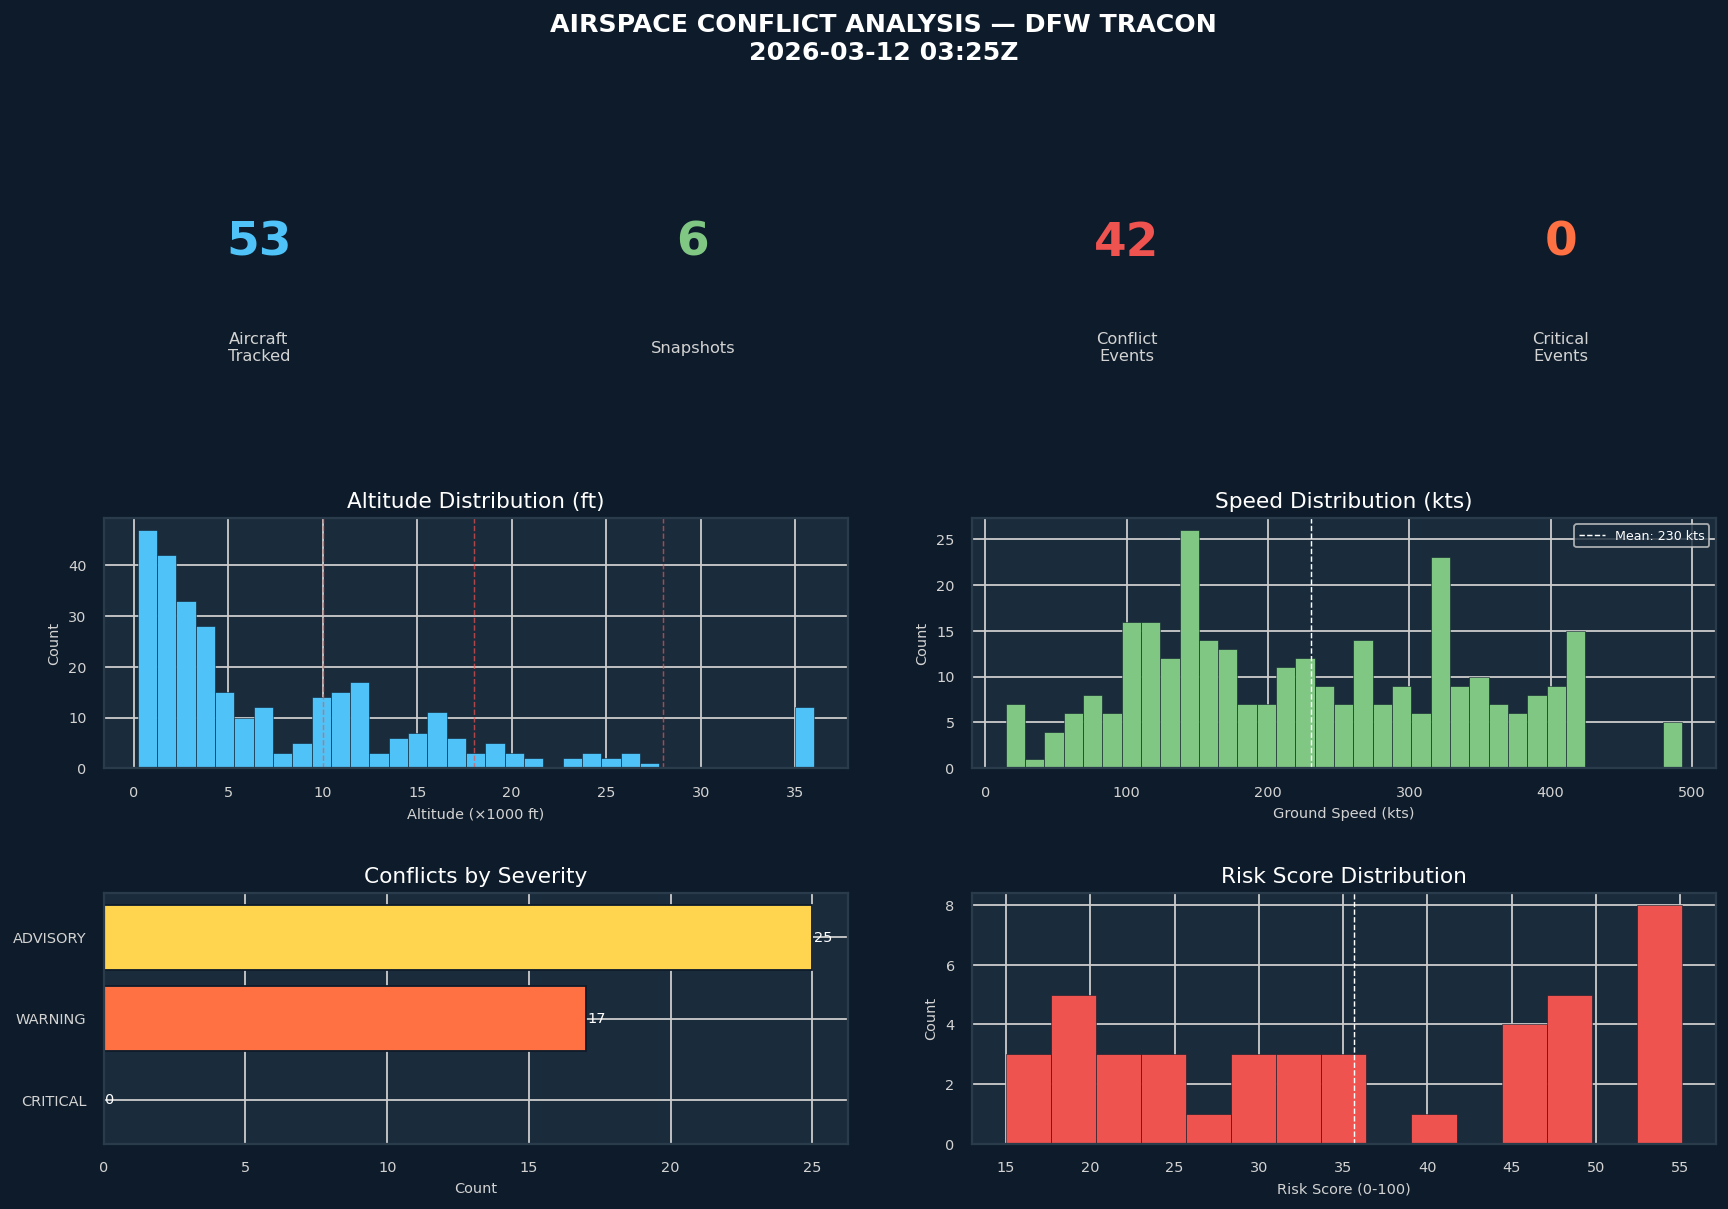

Dashboard saved -> ../outputs/05_executive_dashboard.png


In [2]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#0d1b2a")

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

title = fig.suptitle(
    f"AIRSPACE CONFLICT ANALYSIS — DFW TRACON\n{REPORT_DATE}",
    fontsize=14, fontweight="bold", color="white", y=0.98
)

def dark_ax(ax, title_str):
    ax.set_facecolor("#1a2b3c")
    ax.tick_params(colors="lightgrey", labelsize=8)
    ax.title.set_color("white")
    ax.title.set_fontsize(9)
    ax.set_title(title_str)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2a3b4c")
    return ax

# ── KPI tiles ────────────────────────────────────────────────────────────────
kpis = [
    ("Aircraft\nTracked",    str(df_states["icao24"].nunique()), "#4fc3f7"),
    ("Snapshots",             str(df_states["time"].nunique()),   "#81c784"),
    ("Conflict\nEvents",     str(len(df_conflicts)),             "#ef5350"),
    ("Critical\nEvents",
     str((df_conflicts["severity"]=="CRITICAL").sum()) if has_conflicts else "0",
     "#ff7043"),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor("#1a2b3c")
    ax.axis("off")
    ax.text(0.5, 0.6,  value, ha="center", va="center", fontsize=26,
            fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha="center", va="center", fontsize=9,
            color="lightgrey", transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

# ── Altitude distribution ────────────────────────────────────────────────────
ax2 = dark_ax(fig.add_subplot(gs[1, :2]), "Altitude Distribution (ft)")
ax2.hist(df_states["altitude_ft"] / 1000, bins=35,
         color="#4fc3f7", edgecolor="#0d1b2a", linewidth=0.3)
ax2.set_xlabel("Altitude (×1000 ft)", color="lightgrey", fontsize=8)
ax2.set_ylabel("Count", color="lightgrey", fontsize=8)
for fl in [10, 18, 28]:
    ax2.axvline(fl, color="#ef5350", linestyle="--", alpha=0.7, linewidth=0.8)

# ── Speed distribution ───────────────────────────────────────────────────────
ax3 = dark_ax(fig.add_subplot(gs[1, 2:]), "Speed Distribution (kts)")
ax3.hist(df_states["velocity_kts"], bins=35,
         color="#81c784", edgecolor="#0d1b2a", linewidth=0.3)
ax3.set_xlabel("Ground Speed (kts)", color="lightgrey", fontsize=8)
ax3.set_ylabel("Count", color="lightgrey", fontsize=8)
ax3.axvline(df_states["velocity_kts"].mean(), color="white",
            linestyle="--", linewidth=0.8, label=f'Mean: {df_states["velocity_kts"].mean():.0f} kts')
ax3.legend(fontsize=7, labelcolor="white", facecolor="#1a2b3c")

# ── Severity bar ─────────────────────────────────────────────────────────────
ax4 = dark_ax(fig.add_subplot(gs[2, :2]), "Conflicts by Severity")
if has_conflicts:
    sev_c  = df_conflicts["severity"].value_counts().reindex(
        ["CRITICAL","WARNING","ADVISORY"], fill_value=0)
    colors = ["#ef5350", "#ff7043", "#ffd54f"]
    ax4.barh(sev_c.index, sev_c.values, color=colors, edgecolor="#0d1b2a")
    ax4.set_xlabel("Count", color="lightgrey", fontsize=8)
    for i, v in enumerate(sev_c.values):
        ax4.text(v + 0.05, i, str(v), va="center", color="white", fontsize=8)
else:
    ax4.text(0.5, 0.5, "No conflicts detected", ha="center", va="center",
             color="lightgrey", transform=ax4.transAxes, fontsize=10)

# ── Risk score distribution ───────────────────────────────────────────────────
ax5 = dark_ax(fig.add_subplot(gs[2, 2:]), "Risk Score Distribution")
if has_conflicts and "risk_score" in df_conflicts.columns:
    ax5.hist(df_conflicts["risk_score"], bins=15,
             color="#ef5350", edgecolor="#0d1b2a", linewidth=0.3)
    ax5.set_xlabel("Risk Score (0-100)", color="lightgrey", fontsize=8)
    ax5.set_ylabel("Count", color="lightgrey", fontsize=8)
    ax5.axvline(df_conflicts["risk_score"].mean(), color="white",
                linestyle="--", linewidth=0.8)
else:
    ax5.text(0.5, 0.5, "No conflict data", ha="center", va="center",
             color="lightgrey", transform=ax5.transAxes, fontsize=10)

plt.savefig("../outputs/05_executive_dashboard.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Dashboard saved -> ../outputs/05_executive_dashboard.png")

## Analytical Conclusions

Fill in after running with real data. These would form the verbal brief to your supervisor.

### Traffic Picture
- **Total aircraft tracked:** ___ unique callsigns over ___ snapshots
- **Dominant altitude band:** ___
- **Average ground speed:** ___ kts, consistent with ___

### Conflict Summary
- **___ total separation events** detected across the observation window
- **___ CRITICAL** events (both horizontal AND vertical minimums violated simultaneously)
- **Highest-risk pair:** ___ / ___ with risk score ___

### Spatial Patterns
- Conflicts cluster around ___ (refer to map in notebook 04)
- The ___ altitude band shows the highest conflict rate, likely due to ___

### Recommendations
1. Increased monitoring in the ___ lat/lon area during ___ time windows
2. Review sector loading thresholds — peak of ___ simultaneous aircraft may be approaching capacity
3. Further analysis warranted with larger dataset (recommend N_SNAPSHOTS >= 30)

## Methodology Notes

| Item | Detail |
|---|---|
| Data Source | OpenSky Network ADS-B, anonymous access |
| Sector | Dallas/Fort Worth TRACON (D10) |
| Horizontal Standard | FAA 7110.65, 3 NM terminal separation |
| Vertical Standard | FAA 7110.65, 1,000 ft |
| Conflict Algorithm | Pairwise O(n²) across all airborne pairs per snapshot |
| Risk Score | Composite: separation margin (50%), severity (30%), closing speed (20%) |
| Limitations | ADS-B coverage gaps; position accuracy ±50-200m; no intent data |